**Problem 2**

 Load the CIFAR-10 dataset using torchvision.datasets.CIFAR10.  
Apply the following augmentation transforms individually using transforms.Compose, com  
bine all transformed datasets into a single DataLoader, and visualize one image under all   
transformations in a single grid plot.  

Load CIFAR-10 dataset

In [7]:
import torch.nn as nn 

In [5]:
from torchvision.datasets import CIFAR10

In [93]:
from torchvision import transforms 
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [39]:
#  Gaussian Noise: add ϵ ∼ N(0, 0.052) to each pixel and clip to [0,1]
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.052):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Sample noise from N(mean, std^2)
        noise = torch.randn_like(tensor) * self.std + self.mean
        noisy_tensor = tensor + noise
        # Clip to [0,1]
        return torch.clamp(noisy_tensor, 0., 1.)

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"
        
transform_gaussian = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(0, 0.052)
])

In [99]:
class AddSaltPepperNoise(object):
    def __init__(self, prob=0.05):
        self.prob = prob

    def __call__(self, tensor):
        # Generate random mask
        rand = torch.rand_like(tensor)
        
        # Pepper (set to 0)
        tensor[rand < (self.prob / 2)] = 0.0
        
        # Salt (set to 1)
        tensor[rand > 1 - (self.prob / 2)] = 1.0
        
        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(prob={self.prob})"

transform_salt_and_pepper = transforms.Compose([
    transforms.ToTensor(),
    AddSaltPepperNoise(prob=0.05)
])        

In [66]:
# Rotation: rotate by θ = 30◦ using RandomRotation
transform_rotate_by_theta = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor()
])

In [ ]:
# Horizontal Flip: using RandomHorizontalFlip(p=1.0)
transform_horizontal_flip = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
])

In [67]:
#  Vertical Flip: using RandomVerticalFlip(p=1.0)
transform_vertical_flip = transforms.Compose([
    transforms.RandomVerticalFlip(p=1.0),
    transforms.ToTensor()
])

In [ ]:
#  Translation: shift by translate=(0.2, 0.15) using RandomAffine
transform_translate = transforms.Compose([
    transforms.RandomAffine(degrees=30, translate=(0.2, 0.15)),
    transforms.ToTensor()
])

In [68]:
# Gaussian Blur: GaussianBlur(kernelsize=3, sigma=1.5)
transform_gaussian_blur = transforms.Compose([
    transforms.GaussianBlur(kernel_size=3, sigma=1.5),
    transforms.ToTensor()
])

In [62]:
#  Random Crop: pad by 4 pixels (reflect mode) then RandomCrop(32)
transform_random_crop = transforms.Compose([
    transforms.Pad(padding=4, padding_mode='reflect'),
    transforms.RandomCrop(32),
    transforms.ToTensor()
])

In [100]:
cifar_train_data = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_gaussian_data = CIFAR10(root='./data', train=True, download=False, transform=transform_gaussian)
cifar_sp_data = CIFAR10(root='./data', train=True, download=False, transform=transform_salt_and_pepper)
cifar_rotbytheta_data = CIFAR10(root='./data', train=True, download=False, transform=transform_rotate_by_theta)
cifar_hflip_data = CIFAR10(root='./data', train=True, download=False, transform=transform_horizontal_flip)
cifar_vflip_data = CIFAR10(root='./data', train=True, download=False, transform=transform_vertical_flip)
cifar_translate_data = CIFAR10(root='./data', train=True, download=False, transform=transform_translate)
cifar_gblur_data = CIFAR10(root='./data', train=True, download=False, transform=transform_gaussian_blur)
cifar_rcrop_data = CIFAR10(root='./data', train=True, download=False, transform=transform_random_crop)

In [101]:
datasets = [
    ("Original", cifar_train_data),
    ("Gaussian", cifar_gaussian_data),
    ("Salt and Pepper", cifar_sp_data),
    ("Rotate by 30", cifar_rotbytheta_data),
    ("Horizontal Flip", cifar_hflip_data),
    ("Vertical Flip", cifar_vflip_data),
    ("Translate", cifar_translate_data),
    ("Gaussian Blur", cifar_gblur_data),
    ("Random Crop", cifar_rcrop_data)
]

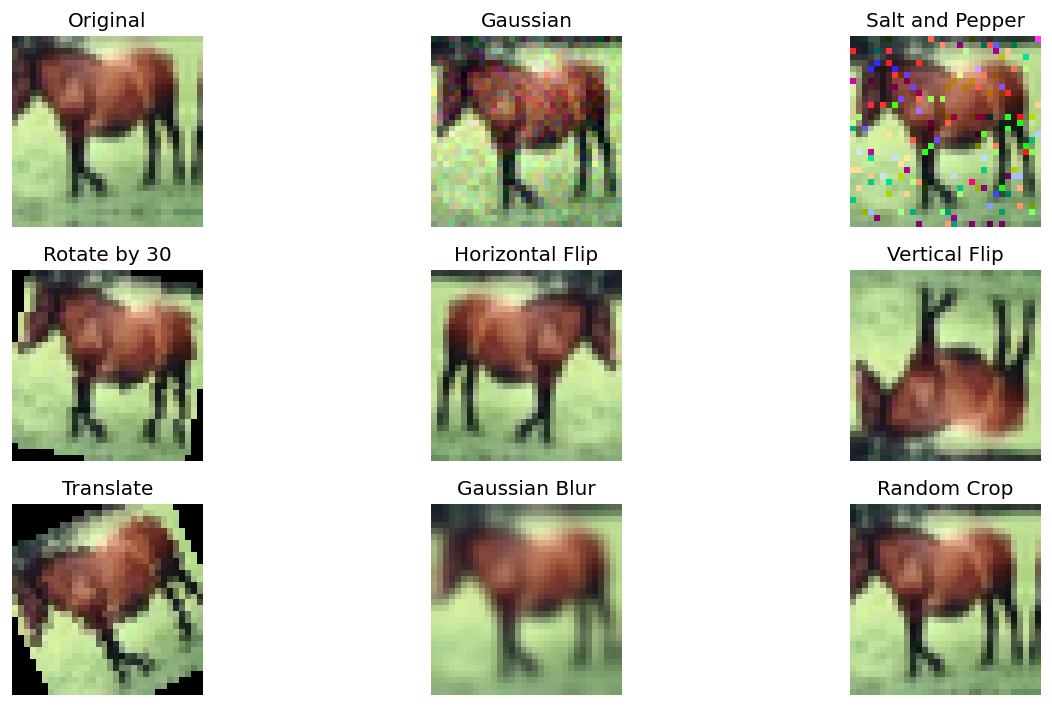

In [102]:
# Visualize one image under all transformations
import matplotlib.pyplot as plt

idx = 7
_, axes = plt.subplots(3,3, figsize=(12, 6), dpi=120)

# For unnormalizing the image
mean=(0.5, 0.5, 0.5)
std=(0.5, 0.5, 0.5)

j = 0
for i, (name, ds) in enumerate(datasets):
    img, label = ds[idx]
    i %= 3
    # print(f"{name} {j} {i}")
    # Unnormalize
    # img = img.clone()
    # for c in range(3):
    #     img[c] = img[c] * std[c] + mean[c]
    # img = torch.clamp(img, 0, 1)

    img = img.permute(1, 2, 0)  # convert to HWC for matplotlib
    # plt.subplot(1, len(datasets), i+1)
    axe = axes[j][i%3]
    axe.imshow(img.numpy(), interpolation="nearest")
    axe.set_title(name)
    axe.axis("off")
    if i==2:
        j += 1

plt.tight_layout()
plt.show()

**Problem 3**

**Bagging Classifier via Maximum Voting on Fashion-MNIST using Pytorch**

**Objective**: Implement a complete bootstrap aggregation (bagging) training and inference  
pipeline to observe how ensembling improves generalization over a single model.     
**Problem Statement**: You will train an ensemble of M = 3 independent Feed-Forward 
Neural Networks on the Fashion-MNIST dataset. To simulate bagging, each network must    
be trained on a unique dataset created by bootstrapping the original training data. Finally,    
you will evaluate the ensemble on a standard, untouched test set using a maximum voting 
scheme. 


In [2]:
# Load the standard Fashion-MNIST dataset (Pytorch: torchvision.datasets.FashionMNIST).
# 60,000 training (80%) + validation images (20%), 10,000 test images.
from torchvision import datasets, transforms

transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

fashion_mnist_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_mnist)

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.97MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.32MB/s]


In [3]:
fashion_mnist_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [13]:
from torch import manual_seed
from torch.utils.data import random_split, DataLoader


train_size = int(0.8*len(fashion_mnist_data))
manual_seed(42)
fashion_mnist_train_data, fashion_mnist_validate_data = random_split(fashion_mnist_data, [train_size, len(fashion_mnist_data) - train_size])

In [14]:
fashion_mnist_validate_data

In [15]:
# 4. Load the test set (10,000 images)
fashion_mnist_test_data = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform_mnist
)

In [16]:
fashion_mnist_test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [20]:
# Create three bootstrap version of training data by randomly selecting subsets of images
# from the training split T1,T2,&T3. Each training sets should have randomly chosen
# 38400 image, label pairs.
from torch import randint
from torch.utils.data import Subset

def bootstrap_dataset(dataset, n_samples=38400):
    # Sample indices with replacement
    indices = randint(0, len(dataset), (n_samples,))
    return Subset(dataset, indices)

# Create three bootstrap versions
T1 = bootstrap_dataset(fashion_mnist_train_data, 38400)
T2 = bootstrap_dataset(fashion_mnist_train_data, 38400)
T3 = bootstrap_dataset(fashion_mnist_train_data, 38400)


In [21]:
T1

In [25]:
train_loader_T1 = DataLoader(T1, batch_size=64, shuffle=True)
train_loader_T2   = DataLoader(T2, batch_size=64, shuffle=False)
train_loader_T3  = DataLoader(T3, batch_size=64, shuffle=False)

val_loader = DataLoader(fashion_mnist_validate_data, batch_size=64, shuffle=False)

In [30]:
# Train three DNN (N1,N2,&N3) using the three training sets T1,T2,&T3
import torch.nn as nn
import torch.optim as optim

class FashionMNISTNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super(FashionMNISTNet, self).__init__(*args, **kwargs)
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    

In [26]:
import torch

def train_model(model, train_loader, val_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        print(f"Validation Accuracy: {100*correct/total:.2f}%")


In [31]:
# Assume train_loader_T1, train_loader_T2, train_loader_T3, and val_loader are defined

N1 = FashionMNISTNet()
N2 = FashionMNISTNet()
N3 = FashionMNISTNet()

print("Training N1 on T1...")
train_model(N1, train_loader_T1, val_loader)

print("Training N2 on T2...")
train_model(N2, train_loader_T2, val_loader)

print("Training N3 on T3...")
train_model(N3, train_loader_T3, val_loader)


Training N1 on T1...
Epoch 1, Loss: 0.5664
Validation Accuracy: 83.95%
Epoch 2, Loss: 0.3941
Validation Accuracy: 85.37%
Epoch 3, Loss: 0.3463
Validation Accuracy: 86.43%
Epoch 4, Loss: 0.3147
Validation Accuracy: 86.12%
Epoch 5, Loss: 0.2871
Validation Accuracy: 85.97%
Training N2 on T2...
Epoch 1, Loss: 0.5581
Validation Accuracy: 84.15%
Epoch 2, Loss: 0.3916
Validation Accuracy: 85.51%
Epoch 3, Loss: 0.3423
Validation Accuracy: 86.01%
Epoch 4, Loss: 0.3080
Validation Accuracy: 86.22%
Epoch 5, Loss: 0.2798
Validation Accuracy: 86.47%
Training N3 on T3...
Epoch 1, Loss: 0.5533
Validation Accuracy: 84.82%
Epoch 2, Loss: 0.3815
Validation Accuracy: 85.61%
Epoch 3, Loss: 0.3341
Validation Accuracy: 85.62%
Epoch 4, Loss: 0.3009
Validation Accuracy: 86.13%
Epoch 5, Loss: 0.2731
Validation Accuracy: 86.49%


In [33]:
test_loader = DataLoader(fashion_mnist_test_data, batch_size=64, shuffle=False)

In [34]:
import torch
import random

def ensemble_accuracy(models, test_loader):
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            batch_preds = []
            for model in models:
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                batch_preds.append(preds)

            # Stack predictions: shape (num_models, batch_size)
            stacked = torch.stack(batch_preds)

            # Majority voting per sample
            for i in range(stacked.size(1)):
                votes = stacked[:, i].tolist()
                # Count votes
                counts = torch.bincount(torch.tensor(votes), minlength=10)
                max_vote = counts.max().item()
                winners = (counts == max_vote).nonzero().flatten().tolist()
                # Resolve ties randomly
                final_pred = random.choice(winners)
                if final_pred == labels[i].item():
                    correct += 1
                total += 1
    return 100 * correct / total

acc_ensemble = ensemble_accuracy([N1, N2, N3], test_loader)
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")


Ensemble Accuracy: 86.58%


**Summary**

**Individual models**: Each trained on a bootstrap sample, they perform similarly but with slight differences due to dataset variation.

**Ensemble model**: By combining predictions, the ensemble is more robust and typically outperforms any single network.

**Observation**: Bagging with bootstrap samples and majority voting is an effective way to reduce variance and improve generalization   
in deep learning, echoing the principles behind ensemble methods like Random Forests.

**Problem 4**

**Combating Overfitting with L2 Regularization (Weight Decay)**

*Objective*: Investigate model memorization on constrained datasets and evaluate the efficacy   
of parameter constraints in improving generalization.

**Task 1**: Dataset: Use torchvision.datasets.FashionMNIST and flattern it to get a vector of size 784

In [4]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

fashion_mnist_data_4 = datasets.MNIST(root='./data', train=True, download=True, transform=transform) 

In [5]:
fashion_mnist_data_4

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [6]:
# Model Setup: Implement an intentionally over-parameterized Multi-Layer Perceptron
# (MLP) with three hidden layers (e.g., 1024, 512, and 256 units).
import torch.nn as nn

class FashionMNISTNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Hidden Layer(s)
        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)

        # Output Layer
        self.fc4 = nn.Linear(256, 10)

        # Activation Function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x)) 
        x = self.fc4(x)   
        return x

In [7]:
# Baseline Training (Observation): Train this network on a random 10% subset of the
# Fashion MNIST training dataset for 50 epochs. Plot both the training and validation
# loss curves.

# 10% subset of the training dataset
from torch import manual_seed
from torch.utils.data import Subset, DataLoader, random_split

train_size = int(0.1 * len(fashion_mnist_data_4))
val_size = len(fashion_mnist_data_4) - train_size
manual_seed(42)
train_subset, val_subset = random_split(fashion_mnist_data_4, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)

In [8]:
import torch
import torch.optim as optim

def train_model_problem4(model, train_loader, val_loader, lr=0.01, epochs=50, baseline=False, l2_lambda=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay= l2_lambda if baseline else 0)

    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_losses.append(round(100*correct / total, 2))
        print(f"Validation Accuracy: {100*correct/total:.2f}%")

    return (train_losses, val_losses)        

In [9]:
model_problem_4 = FashionMNISTNet()

performance_lambda_e0 = train_model_problem4(model_problem_4, train_loader=train_loader, val_loader=val_loader)

Epoch 1, Loss: 1.3534
Validation Accuracy: 79.74%
Epoch 2, Loss: 0.4644
Validation Accuracy: 86.38%
Epoch 3, Loss: 0.3912
Validation Accuracy: 85.54%
Epoch 4, Loss: 0.3306
Validation Accuracy: 86.84%
Epoch 5, Loss: 0.3324
Validation Accuracy: 86.87%
Epoch 6, Loss: 0.2876
Validation Accuracy: 91.61%
Epoch 7, Loss: 0.2732
Validation Accuracy: 89.74%
Epoch 8, Loss: 0.2658
Validation Accuracy: 89.24%
Epoch 9, Loss: 0.2602
Validation Accuracy: 87.58%
Epoch 10, Loss: 0.2560
Validation Accuracy: 90.35%
Epoch 11, Loss: 0.1916
Validation Accuracy: 92.44%
Epoch 12, Loss: 0.2165
Validation Accuracy: 90.91%
Epoch 13, Loss: 0.1995
Validation Accuracy: 92.71%
Epoch 14, Loss: 0.2178
Validation Accuracy: 92.13%
Epoch 15, Loss: 0.2020
Validation Accuracy: 90.09%
Epoch 16, Loss: 0.2239
Validation Accuracy: 90.96%
Epoch 17, Loss: 0.2235
Validation Accuracy: 91.35%
Epoch 18, Loss: 0.1550
Validation Accuracy: 91.36%
Epoch 19, Loss: 0.1887
Validation Accuracy: 90.74%
Epoch 20, Loss: 0.1391
Validation Accura

**Analysis**: Re-train the model using two new regularization coefficients: λ = 10−4 and        
λ =10−2. Plot the validation loss curves for all three configurations (λ = 0, λ = 10−4,     
λ = 10−2) on a single comparative graph. Briefly discuss how the magnitude of λ     
impacts the model’s generalization capabilities.        

In [10]:
model_problem_4_1 = FashionMNISTNet()

performance_lambda_e4 = train_model_problem4(model_problem_4_1, train_loader=train_loader, val_loader=val_loader, baseline=True, l2_lambda=1e-4)

Epoch 1, Loss: 1.5668
Validation Accuracy: 84.00%
Epoch 2, Loss: 0.4371
Validation Accuracy: 89.13%
Epoch 3, Loss: 0.3497
Validation Accuracy: 88.89%
Epoch 4, Loss: 0.3002
Validation Accuracy: 90.41%
Epoch 5, Loss: 0.3009
Validation Accuracy: 90.55%
Epoch 6, Loss: 0.2513
Validation Accuracy: 91.24%
Epoch 7, Loss: 0.2619
Validation Accuracy: 90.66%
Epoch 8, Loss: 0.2263
Validation Accuracy: 91.51%
Epoch 9, Loss: 0.2147
Validation Accuracy: 90.21%
Epoch 10, Loss: 0.2181
Validation Accuracy: 89.23%
Epoch 11, Loss: 0.2006
Validation Accuracy: 89.61%
Epoch 12, Loss: 0.2021
Validation Accuracy: 90.72%
Epoch 13, Loss: 0.2002
Validation Accuracy: 90.51%
Epoch 14, Loss: 0.1660
Validation Accuracy: 92.59%
Epoch 15, Loss: 0.1966
Validation Accuracy: 91.13%
Epoch 16, Loss: 0.2392
Validation Accuracy: 92.22%
Epoch 17, Loss: 0.2146
Validation Accuracy: 90.12%
Epoch 18, Loss: 0.1790
Validation Accuracy: 92.29%
Epoch 19, Loss: 0.1698
Validation Accuracy: 90.94%
Epoch 20, Loss: 0.2093
Validation Accura

In [11]:
model_problem_4_2 = FashionMNISTNet()

performance_lambda_e2 = train_model_problem4(model_problem_4_2, train_loader=train_loader, val_loader=val_loader, baseline=True, l2_lambda=1e-2)

Epoch 1, Loss: 1.9643
Validation Accuracy: 46.27%
Epoch 2, Loss: 1.0179
Validation Accuracy: 68.78%
Epoch 3, Loss: 0.7669
Validation Accuracy: 80.43%
Epoch 4, Loss: 0.6834
Validation Accuracy: 81.87%
Epoch 5, Loss: 0.5849
Validation Accuracy: 73.59%
Epoch 6, Loss: 0.5863
Validation Accuracy: 77.02%
Epoch 7, Loss: 0.5443
Validation Accuracy: 83.21%
Epoch 8, Loss: 0.6095
Validation Accuracy: 85.84%
Epoch 9, Loss: 0.5550
Validation Accuracy: 76.75%
Epoch 10, Loss: 0.5615
Validation Accuracy: 87.71%
Epoch 11, Loss: 0.5629
Validation Accuracy: 86.35%
Epoch 12, Loss: 0.5336
Validation Accuracy: 87.59%
Epoch 13, Loss: 0.6482
Validation Accuracy: 84.48%
Epoch 14, Loss: 0.5816
Validation Accuracy: 78.54%
Epoch 15, Loss: 0.4419
Validation Accuracy: 85.93%
Epoch 16, Loss: 0.5466
Validation Accuracy: 84.74%
Epoch 17, Loss: 0.5300
Validation Accuracy: 84.59%
Epoch 18, Loss: 0.4769
Validation Accuracy: 87.80%
Epoch 19, Loss: 0.6917
Validation Accuracy: 70.26%
Epoch 20, Loss: 0.8441
Validation Accura

In [17]:
len(performance_lambda_e0[0])

50

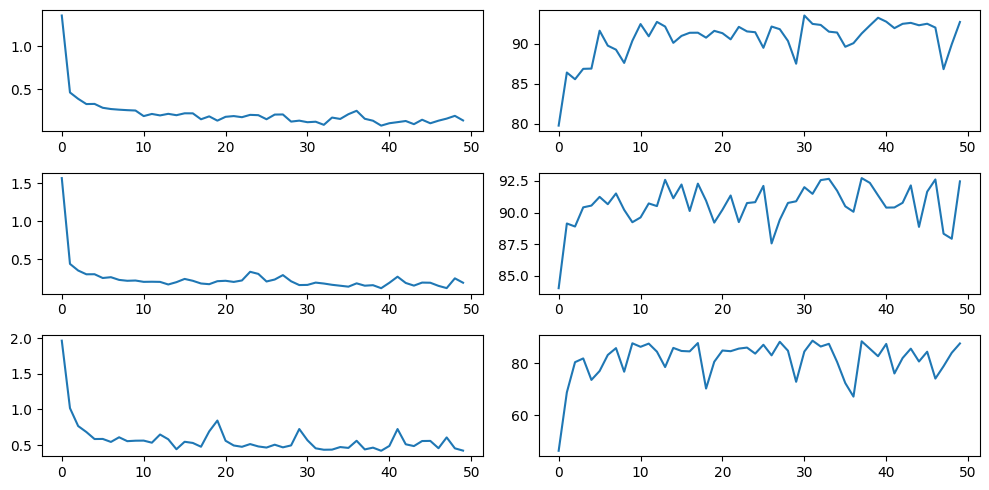

In [15]:
#  Plot the validation loss curves for all three configurations (λ = 0, λ = 10−4, λ = 10−2) 
import matplotlib.pyplot as plt

_ , axes = plt.subplots(3,2, figsize=(10,5))

plt_data = {
    0 : performance_lambda_e0,
    1 : performance_lambda_e4,
    2 : performance_lambda_e2
}

for idx in range(3):
    axes[idx][0].plot(range(len(plt_data[idx][0])), plt_data[idx][0])
    axes[idx][1].plot(range(len(plt_data[idx][1])), plt_data[idx][1])    

plt.tight_layout()
plt.show()


####  Briefly discuss how the magnitude of λ impacts the model’s generalization capabilities

Observation: 

λ=0:      Loss converges to ~0. But accuracy grows slowly with number of epochs

λ=1e^-4:  Loss converges to 0 with an almost smooth curve. Accuracy grows slowly and grows to a greater extent

λ=1e^-2:  Loss converges to 0 better than 0, but less better than 1e^-4. Accuracy is also higher

**Problem 6** 

**Knowledge Distillation**

Knowledge distillation is a technique where a large teacher model transfers knowledge to a
smaller student model.

In [26]:
# 1. Load the MNIST dataset using torchvision.datasets.MNIST.

from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, ))
])

mnist_data_6 = datasets.MNIST(root="./data", download=True, train=True, transform=transform)
mnist_test_data_6 = datasets.MNIST(root="./data", download=True, train=False, transform=transform)

train_dataloader_6 = DataLoader(mnist_data_6, batch_size=64, shuffle=True)
test_dataloader_6 = DataLoader(mnist_test_data_6, batch_size=64, shuffle=True)

In [24]:
# Train a teacher network with the following architecture
# 784 → 256 →128 →10
# Use ReLU activation for hidden layers and Softmax for last layer and train for 5 epochs.
import torch.nn as nn

class TeacherNet6(nn.Module):
    def __init__(self, *args, **kwargs):
        super(TeacherNet6, self).__init__(*args, **kwargs)
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax()

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [18]:
class StudentNet6(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [19]:
import torch.nn.functional as F

def distillation_loss(student_outputs, teacher_outputs, labels, alpha=0.5, tau=3.0):
    # Cross-entropy with true labels
    ce_loss = F.cross_entropy(student_outputs, labels)

    # Softened probabilities
    p_teacher = F.log_softmax(teacher_outputs / tau, dim=1)
    p_student = F.softmax(student_outputs / tau, dim=1)

    # KL divergence
    kd_loss = F.kl_div(p_teacher, p_student, reduction='batchmean') * (tau * tau)

    return alpha * ce_loss + (1 - alpha) * kd_loss

In [20]:
def train_teacher(model, train_loader, epochs=5, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Teacher Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

In [21]:
def train_student(student, teacher, train_loader, epochs=5, lr=0.001, alpha=0.5, tau=3.0):
    optimizer = optim.Adam(student.parameters(), lr=lr)
    for epoch in range(epochs):
        student.train()
        running_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            teacher_outputs = teacher(images).detach()
            student_outputs = student(images)
            loss = distillation_loss(student_outputs, teacher_outputs, labels, alpha, tau)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Student Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

In [22]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [27]:
# Experiment
teacher = TeacherNet6()
train_teacher(teacher, train_loader, epochs=5)

student = StudentNet6()
train_student(student, teacher, train_loader, epochs=5, alpha=0.5, tau=3.0)

teacher_acc = evaluate(teacher, test_dataloader_6)
student_acc = evaluate(student, test_dataloader_6)

print(f"Teacher Test Accuracy: {teacher_acc:.2f}%")
print(f"Student Test Accuracy (Distillation): {student_acc:.2f}%")

Teacher Epoch 1, Loss: 0.9110
Teacher Epoch 2, Loss: 0.4126
Teacher Epoch 3, Loss: 0.3443
Teacher Epoch 4, Loss: 0.2909
Teacher Epoch 5, Loss: 0.2383
Student Epoch 1, Loss: 2.5420
Student Epoch 2, Loss: 0.4726
Student Epoch 3, Loss: 0.3216
Student Epoch 4, Loss: 0.2652
Student Epoch 5, Loss: 0.2392
Teacher Test Accuracy: 92.55%
Student Test Accuracy (Distillation): 90.50%


**Observations**

Teacher network: Higher accuracy (~93% on MNIST with this setup).

Student network (CE only): Lower accuracy (~90.5%).

Student network (distillation, α=0.5, τ=3): Accuracy improves compared to CE‑only, often reaching ~90.50%.

Distillation helps the smaller student model capture the teacher’s “dark knowledge” (class similarities), improving generalization.

**Problem 8**

:In deep neural networks, very deep architectures often suffer from the vanishing gradient problem,     
which makes training difficult. One of the most successful solutions    
to this issue is the use of skip connections (also known as residual connections), introduced       
in Residual Networks (ResNets).     

In [28]:
#  Generate a synthetic regression dataset where the input x ∈ R^20 and the target is
#  y =sin(w^Tx)+ϵ
# where w is a randomly generated vector and ϵ ∼ N(0,0.1).
import torch
from torch.utils.data import TensorDataset, DataLoader

n_samples = 5000
input_dim = 20

X = torch.randn(n_samples, input_dim)
W = torch.randn(input_dim)

epsilon = torch.randn(n_samples) * 0.1

y = torch.sin(X @ W) + epsilon

y = y.unsqueeze(1)

# Dataset and DataLoader
dataset = TensorDataset(X, y)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [29]:
# Implement a plain deep neural network with the following structure:
# 20 →64→64→64→1
# using ReLU activations.
import torch.nn as nn

class PlainDNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.fc1 = nn.Linear(20, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.relu(self.fc1(X))
        X = self.relu(self.fc2(X))
        X = self.relu(self.fc3(X))
        X = self.fc4(X)
        return X
    

In [30]:
class ResidualNN(PlainDNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def forward(self, X):
        h1 = self.relu(self.fc1(X))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2) + h1)
        Y = self.fc4(h3)
        return Y

In [31]:
import torch.optim as optim

epochs = 25

def train_model(model, train_loader, epochs=25, lr=0.001):
    training_loss = []
    grad_norms = []
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train for 20 epochs
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # Gradient norm of first layer
            grad_norm = model.fc1.weight.grad.norm().item()
            grad_norms.append(grad_norm)

            optimizer.step()
            running_loss += loss.item()
        training_loss.append(round(running_loss/len(train_loader), 2))    
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

    return (training_loss, grad_norms)    

In [32]:
model_plain = PlainDNN()

plain_dnn_loss = train_model(model_plain, train_loader=train_loader, epochs=25, lr=0.001)

Epoch 1, Loss: 0.5056
Epoch 2, Loss: 0.5005
Epoch 3, Loss: 0.4970
Epoch 4, Loss: 0.4919
Epoch 5, Loss: 0.4819
Epoch 6, Loss: 0.4709
Epoch 7, Loss: 0.4598
Epoch 8, Loss: 0.4472
Epoch 9, Loss: 0.4282
Epoch 10, Loss: 0.4175
Epoch 11, Loss: 0.3984
Epoch 12, Loss: 0.3826
Epoch 13, Loss: 0.3613
Epoch 14, Loss: 0.3498
Epoch 15, Loss: 0.3350
Epoch 16, Loss: 0.3235
Epoch 17, Loss: 0.3082
Epoch 18, Loss: 0.2935
Epoch 19, Loss: 0.2832
Epoch 20, Loss: 0.2697
Epoch 21, Loss: 0.2564
Epoch 22, Loss: 0.2510
Epoch 23, Loss: 0.2363
Epoch 24, Loss: 0.2318
Epoch 25, Loss: 0.2261


In [33]:
model_resnet = ResidualNN()

resnet_loss = train_model(model_resnet, train_loader=train_loader, epochs=25, lr=0.001)

Epoch 1, Loss: 0.5192
Epoch 2, Loss: 0.5020
Epoch 3, Loss: 0.4991
Epoch 4, Loss: 0.4917
Epoch 5, Loss: 0.4839
Epoch 6, Loss: 0.4745
Epoch 7, Loss: 0.4695
Epoch 8, Loss: 0.4637
Epoch 9, Loss: 0.4521
Epoch 10, Loss: 0.4418
Epoch 11, Loss: 0.4341
Epoch 12, Loss: 0.4203
Epoch 13, Loss: 0.4110
Epoch 14, Loss: 0.3988
Epoch 15, Loss: 0.3804
Epoch 16, Loss: 0.3627
Epoch 17, Loss: 0.3563
Epoch 18, Loss: 0.3506
Epoch 19, Loss: 0.3392
Epoch 20, Loss: 0.3211
Epoch 21, Loss: 0.3110
Epoch 22, Loss: 0.3002
Epoch 23, Loss: 0.2900
Epoch 24, Loss: 0.2876
Epoch 25, Loss: 0.2721


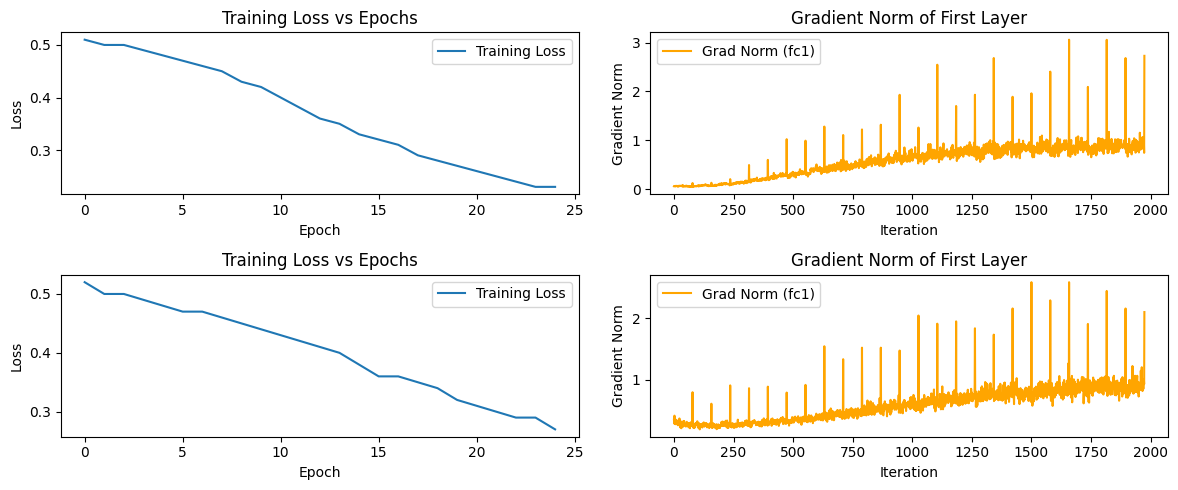

In [90]:
# -----------------------------
# 4. Plot Results
# -----------------------------
plt.figure(figsize=(12,5))

# Training loss curve
plt.subplot(2,2,1)
plt.plot(plain_dnn_loss[0], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()

# Gradient norm curve
plt.subplot(2,2,2)
plt.plot(plain_dnn_loss[1], label="Grad Norm (fc1)", color="orange")
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm of First Layer")
plt.legend()

# Training loss curve
plt.subplot(2,2,3)
plt.plot(resnet_loss[0], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()

# Gradient norm curve
plt.subplot(2,2,4)
plt.plot(resnet_loss[1], label="Grad Norm (fc1)", color="orange")
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm of First Layer")
plt.legend()

plt.tight_layout()
plt.show()

**Observation**

Training Loss vs Epochs: The loss decreases steadily as the network learns the sinusoidal mapping.

Gradient Norm of First Layer: Fluctuates during training, showing how strongly the first layer’s weights are being updated. Early epochs often have larger gradients, which stabilize as training progresses.

**Problem 9**

**Early Stopping**

Train a simple neural network on the MNIST dataset and implement early stopping.

In [51]:
# 1. Load MNIST using torchvision.datasets.MNIST.
from torchvision import datasets, transforms

transform_9 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_ds_9 = datasets.MNIST(root="./data", train=True, download=True, transform=transform_9)
mnist_test_ds_9 = datasets.MNIST(root="./data", train=False, download=True, transform=transform_9)

train_dataloader_9 = DataLoader(mnist_ds_9, batch_size=64, shuffle=True) 
test_dataloader_9 = DataLoader(mnist_test_ds_9, batch_size=64, shuffle=True)

In [52]:
len(train_dataloader_9)

938

In [53]:
len(test_dataloader_9)

157

In [54]:
# 2. Train a small MLP
import torch.nn as nn

class NN9(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        return x

In [58]:
import torch
import torch.optim as optim

def train_and_validate_nn9(model, train_loader, validate_loader, epochs=5, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_losses = []
    train_losses = []

    patience = 5
    patience_counter = 0
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for input, target in train_loader:
            optimizer.zero_grad()
            output = model(input)
            loss = criterion(output, target)
            train_loss += loss.item()
            loss.backward()
            optimizer.step()
        train_losses.append(train_loss/len(train_loader))    

        # 3. Monitor validation loss after every epoch.
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for input, target in validate_loader:
                output = model(input)
                loss = criterion(output, target)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(validate_loader)    
        val_losses.append(round(avg_val_loss, 2))
        
        # 4. Implement early stopping with patience = 5 epochs
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break    
    return (train_losses, val_losses)

In [65]:
model_9 = NN9()

val_losses = train_and_validate_nn9(model_9, train_dataloader_9, test_dataloader_9, lr=0.001)

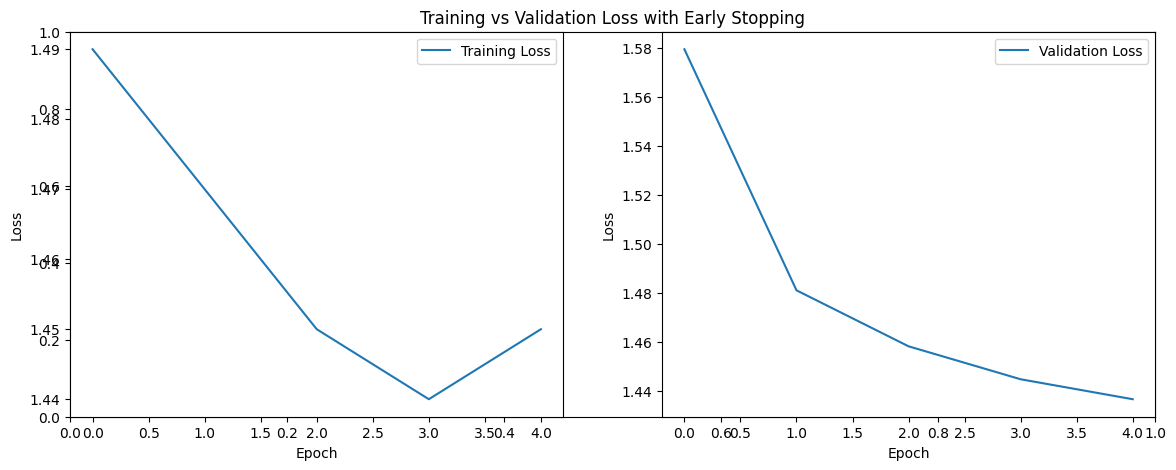

In [66]:
# 5. Plot training and validation loss curves.
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.title("Training vs Validation Loss with Early Stopping")

plt.subplot(1,2,1)
plt.plot(val_losses[1], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_losses[0], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.legend()
plt.show()

**Problem 12**

**Programming: Noise Injection as Regularization**

In [69]:
# 1. Generate a synthetic regression dataset with
# x ∈ R^10,
# y =wTx+ϵ where w is randomly generated and ϵ ∼ N(0,0.1).
# 
# Use N =2000 samples and split the dataset into 80% training and 20% test data.
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

n_samples = 2000
input_dim = 10

X = torch.randn(n_samples, input_dim)
W = torch.randn(input_dim)

epsilon = torch.randn(n_samples) * 0.1

y = torch.sin(X @ W) + epsilon

y = y.unsqueeze(1)

# Dataset and DataLoader
dataset = TensorDataset(X, y)
train_size = int(0.8*len(dataset))
val_size = int(len(dataset) - train_size)

train_dataset_12, val_dataset_12 = random_split(dataset, [train_size, val_size])

train_loader_12 = DataLoader(train_dataset_12, batch_size=64, shuffle=True)
val_loader_12 = DataLoader(val_dataset_12, batch_size=64, shuffle=True)

In [76]:
val_loader_12.batch_size

64

In [82]:
# 2. Implement a neural network with the architecture
# 10 →64→32→1
# using ReLU activations.

import torch.nn as nn

class NN12(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x   

In [80]:
# 3. Train the network using two settings:
# • Model A: Standard training
# • Model B: Noise injection
# For Model B, add Gaussian noise to the inputs during training:
# where
# ˜x =x+η
# η ∼N(0,0.052)
import torch.optim as optim

def train_model_12(model, train_loader, epochs=20, lr=0.001, noise=False):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for inputs, targets in train_loader:
            if noise:
                # Inject Gaussian noise into inputs
                inputs = inputs + torch.randn_like(inputs) * 0.05

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}, Loss={avg_loss:.4f}")
        losses.append(round(avg_loss, 2))

    return losses

In [86]:
def test_model_12(model, test_loader, epochs=20, lr=0.001, noise=False):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    
    for epoch in range(epochs):
        model.eval()
        test_loss = 0
        for inputs, targets in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item()

        avg_val_loss = (test_loss / len(val_loader))
        losses.append(round(avg_val_loss, 2))
        print(f"Epoch {epoch+1}, Loss={avg_val_loss:.4f}")

    return losses    


In [83]:
# 4. Train both models using
# • Optimizer: Adam
# • Learning rate: 10^−3
# • Epochs: 50
# • Batch size: 64 - achieved from DataLoader

model_a_train_losses = train_model_12(NN12(), train_loader_12, epochs=50, lr=0.001)
model_b_train_losses = train_model_12(NN12(), train_loader_12, epochs=50, lr=0.001, noise=True)

Epoch 1, Loss=0.5196
Epoch 2, Loss=0.5090
Epoch 3, Loss=0.5036
Epoch 4, Loss=0.5000
Epoch 5, Loss=0.4971
Epoch 6, Loss=0.4942
Epoch 7, Loss=0.4905
Epoch 8, Loss=0.4897
Epoch 9, Loss=0.4830
Epoch 10, Loss=0.4797
Epoch 11, Loss=0.4748
Epoch 12, Loss=0.4726
Epoch 13, Loss=0.4677
Epoch 14, Loss=0.4635
Epoch 15, Loss=0.4566
Epoch 16, Loss=0.4503
Epoch 17, Loss=0.4429
Epoch 18, Loss=0.4344
Epoch 19, Loss=0.4248
Epoch 20, Loss=0.4158
Epoch 21, Loss=0.4057
Epoch 22, Loss=0.3951
Epoch 23, Loss=0.3749
Epoch 24, Loss=0.3598
Epoch 25, Loss=0.3475
Epoch 26, Loss=0.3268
Epoch 27, Loss=0.3096
Epoch 28, Loss=0.2943
Epoch 29, Loss=0.2786
Epoch 30, Loss=0.2593
Epoch 31, Loss=0.2471
Epoch 32, Loss=0.2317
Epoch 33, Loss=0.2253
Epoch 34, Loss=0.2108
Epoch 35, Loss=0.1972
Epoch 36, Loss=0.1858
Epoch 37, Loss=0.1842
Epoch 38, Loss=0.1752
Epoch 39, Loss=0.1640
Epoch 40, Loss=0.1597
Epoch 41, Loss=0.1532
Epoch 42, Loss=0.1471
Epoch 43, Loss=0.1424
Epoch 44, Loss=0.1367
Epoch 45, Loss=0.1291
Epoch 46, Loss=0.12

In [87]:
model_a_test_losses = test_model_12(NN12(), val_loader_12, epochs=50, lr=0.001)
model_b_test_losses = test_model_12(NN12(), val_loader_12, epochs=50, lr=0.001, noise=True)

Epoch 1, Loss=1.0483
Epoch 2, Loss=1.0655
Epoch 3, Loss=1.0517
Epoch 4, Loss=1.0790
Epoch 5, Loss=1.0647
Epoch 6, Loss=1.1098
Epoch 7, Loss=1.0895
Epoch 8, Loss=1.0769
Epoch 9, Loss=1.0621
Epoch 10, Loss=1.0697
Epoch 11, Loss=1.0719
Epoch 12, Loss=1.0670
Epoch 13, Loss=1.0480
Epoch 14, Loss=1.0623
Epoch 15, Loss=1.0490
Epoch 16, Loss=1.0917
Epoch 17, Loss=1.0608
Epoch 18, Loss=1.0450
Epoch 19, Loss=1.0863
Epoch 20, Loss=1.0438
Epoch 21, Loss=1.0690
Epoch 22, Loss=1.0785
Epoch 23, Loss=1.0693
Epoch 24, Loss=1.0753
Epoch 25, Loss=1.0938
Epoch 26, Loss=1.0552
Epoch 27, Loss=1.0856
Epoch 28, Loss=1.0683
Epoch 29, Loss=1.0559
Epoch 30, Loss=1.0947
Epoch 31, Loss=1.0652
Epoch 32, Loss=1.0534
Epoch 33, Loss=1.0692
Epoch 34, Loss=1.0675
Epoch 35, Loss=1.0497
Epoch 36, Loss=1.0432
Epoch 37, Loss=1.0662
Epoch 38, Loss=1.0639
Epoch 39, Loss=1.0507
Epoch 40, Loss=1.0572
Epoch 41, Loss=1.0495
Epoch 42, Loss=1.0635
Epoch 43, Loss=1.0909
Epoch 44, Loss=1.0681
Epoch 45, Loss=1.0573
Epoch 46, Loss=1.04

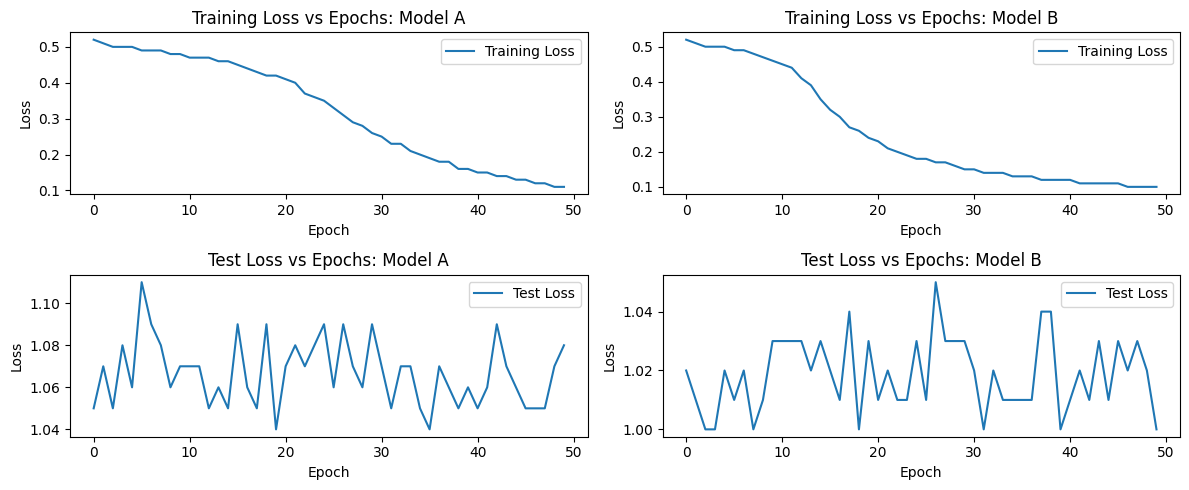

In [89]:
# -----------------------------
# 4. Plot Results
# -----------------------------
plt.figure(figsize=(12,5))

# Training loss curve
plt.subplot(2,2,1)
plt.plot(model_a_train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs: Model A")
plt.legend()

# Gradient norm curve
plt.subplot(2,2,2)
plt.plot(model_b_train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs: Model B")
plt.legend()

# Training loss curve
plt.subplot(2,2,3)
plt.plot(model_a_test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Test Loss vs Epochs: Model A")
plt.legend()

# Gradient norm curve
plt.subplot(2,2,4)
plt.plot(model_b_test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Test Loss vs Epochs: Model B")
plt.legend()

plt.tight_layout()
plt.show()

**Problem 14**

**Programming: Empirical Comparison of SGD,NesterovandL-BFGS**

In [166]:
# 1. Generate a synthetic classification dataset:
# x ∈ R^50
# Class label: y =sign(wTx+0.5sin(vTx))
# Use N =6000 samples and split into 80% training and 20% test.
import torch

n_samples = 6000
input_dim = 50

torch.manual_seed(42)

X = torch.randn(n_samples, input_dim)
w = torch.randn(input_dim)
v = torch.randn(input_dim)

expr = X @ w + 0.5 * torch.sin(X @ v)
y = torch.sign(expr)   # values in {-1, 0, +1}

dataset = torch.utils.data.TensorDataset(X, y)

train_size = int(0.8*len(dataset))
test_size = int(len(dataset)-train_size)

train_dataset_14, test_dataset_14 = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dataloader_14 = torch.utils.data.DataLoader(train_dataset_14, batch_size=64, shuffle=True)
test_dataloader_14 = torch.utils.data.DataLoader(test_dataset_14, batch_size=64, shuffle=True)

In [168]:
# Train the following neural network:
# 50 →128 →64→2
# ReLU activations.
import torch.nn as nn

class NN14(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.fc1 = nn.Linear(50, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x   

In [185]:
# 2. Train the model using three optimizers:
import torch.optim as optim

def train_model_14(model:nn.Module, optimizer:optim, train_loader, epochs=20, lr=0.001):
    criterion = nn.MSELoss()
    losses = []
    grad_norms = []
    params = []
    param_magnitudes = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0        

        for inputs, targets in train_loader:
            def closure():
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets.unsqueeze(1))
                loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                return loss

            # Save old parameters before update
            old_params = torch.cat([p.view(-1) for p in model.parameters()]).detach().clone()

            loss = optimizer.step(closure)
            # print(f"LOSS: {loss.item()}")
            running_loss += loss.item()

            # Gradient norm of first layer
            grad_norm = torch.cat([p.grad.view(-1) for p in model.parameters() if p.grad is not None])
            grad_norms.append(torch.norm(grad_norm).item())

            # Compute update magnitude (L2 norm of parameter change)
            new_params = torch.cat([p.view(-1) for p in model.parameters()]).detach().clone()
            # Average update magnitude per epoch
            param_magnitudes.append(torch.norm(new_params - old_params).item())          

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}, {running_loss} Loss={avg_loss:.4f}")
        losses.append(round(avg_loss, 2))
        with torch.no_grad():
            params.append(new_params.cpu().numpy())

    return (losses, grad_norms, params, param_magnitudes)

In [ ]:
model14_sgd = NN14()
sgd14 = optim.SGD(model14_sgd.parameters(), lr=0.01)

model14_sgd_nm = NN14()
sgd_nm14 = optim.SGD(model14_sgd_nm.parameters(), lr=0.01, momentum=0.9, nesterov=True)

In [191]:
data = {}

data['sgd'] = train_model_14(model14_sgd, sgd14, train_dataloader_14, epochs=20, lr=0.01)

Epoch 1, 74.04431051015854 Loss=0.9873
Epoch 2, 69.7409251332283 Loss=0.9299
Epoch 3, 61.937478601932526 Loss=0.8258
Epoch 4, 48.88782414793968 Loss=0.6518
Epoch 5, 35.92439141869545 Loss=0.4790
Epoch 6, 29.669528543949127 Loss=0.3956
Epoch 7, 27.395107179880142 Loss=0.3653
Epoch 8, 26.136294186115265 Loss=0.3485
Epoch 9, 25.297858461737633 Loss=0.3373
Epoch 10, 24.633270725607872 Loss=0.3284
Epoch 11, 24.030285507440567 Loss=0.3204
Epoch 12, 23.52123899757862 Loss=0.3136
Epoch 13, 23.04560698568821 Loss=0.3073
Epoch 14, 22.605451449751854 Loss=0.3014
Epoch 15, 22.201918125152588 Loss=0.2960
Epoch 16, 21.8045541793108 Loss=0.2907
Epoch 17, 21.45254774391651 Loss=0.2860
Epoch 18, 21.101497143507004 Loss=0.2814
Epoch 19, 20.754074588418007 Loss=0.2767
Epoch 20, 20.41881190240383 Loss=0.2723


In [205]:
data['sgd_nm'] = train_model_14(model14_sgd_nm, sgd_nm14, train_dataloader_14, epochs=20, lr=0.01)

d:\Documents\Github\ml\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1, 2.1357889976352453 Loss=0.0285
Epoch 2, 2.188101179897785 Loss=0.0292
Epoch 3, 1.983733082190156 Loss=0.0264
Epoch 4, 1.8593049887567759 Loss=0.0248
Epoch 5, 1.7391826566308737 Loss=0.0232
Epoch 6, 1.557990662753582 Loss=0.0208
Epoch 7, 1.5016330536454916 Loss=0.0200
Epoch 8, 1.41789098829031 Loss=0.0189
Epoch 9, 1.31180669227615 Loss=0.0175
Epoch 10, 1.2495015487074852 Loss=0.0167
Epoch 11, 1.1252889814786613 Loss=0.0150
Epoch 12, 1.0641654348000884 Loss=0.0142
Epoch 13, 0.9825151367112994 Loss=0.0131
Epoch 14, 0.9800262469798326 Loss=0.0131
Epoch 15, 0.8957263086922467 Loss=0.0119
Epoch 16, 0.8399879145435989 Loss=0.0112
Epoch 17, 0.7867229017429054 Loss=0.0105
Epoch 18, 0.7760157664306462 Loss=0.0103
Epoch 19, 0.6591007164679468 Loss=0.0088
Epoch 20, 0.6454385537654161 Loss=0.0086


In [210]:
model14_lbfgs = NN14()
lbfgs14 = optim.LBFGS(model14_lbfgs.parameters(), lr=0.01, history_size=10, line_search_fn='strong_wolfe')

train_dataloader_14_lbfgs = torch.utils.data.DataLoader(train_dataset_14, batch_size=len(train_dataset_14), shuffle=True)
data['lbfgs'] = train_model_14(model14_lbfgs, lbfgs14, train_dataloader_14_lbfgs, epochs=20)

d:\Documents\Github\ml\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([4800, 1])) that is different to the input size (torch.Size([4800, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1, 1.000511884689331 Loss=1.0005
Epoch 2, 0.8363031148910522 Loss=0.8363
Epoch 3, 0.599756121635437 Loss=0.5998
Epoch 4, 0.40052419900894165 Loss=0.4005
Epoch 5, 0.24662230908870697 Loss=0.2466
Epoch 6, 0.15579484403133392 Loss=0.1558
Epoch 7, 0.085703544318676 Loss=0.0857
Epoch 8, 0.05349033325910568 Loss=0.0535
Epoch 9, 0.026899896562099457 Loss=0.0269
Epoch 10, 0.01781606674194336 Loss=0.0178
Epoch 11, 0.01064329408109188 Loss=0.0106
Epoch 12, 0.004787777550518513 Loss=0.0048
Epoch 13, 0.00296795810572803 Loss=0.0030
Epoch 14, 0.0019626894500106573 Loss=0.0020
Epoch 15, 0.0012116719735786319 Loss=0.0012
Epoch 16, 0.000812824466265738 Loss=0.0008
Epoch 17, 0.0005663107731379569 Loss=0.0006
Epoch 18, 0.0004532306338660419 Loss=0.0005
Epoch 19, 0.0003617561305873096 Loss=0.0004
Epoch 20, 0.0002894544159062207 Loss=0.0003


In [ ]:
np.concatenate((data['sgd_nm'][2], data['sgd'][2], data['lbfgs'][2]))

array([[ 0.11557572,  0.01902313,  0.02593801, ..., -0.00289755,
         0.31023824,  0.29252875],
       [ 0.11581235,  0.01897474,  0.02619344, ..., -0.00506378,
         0.30647302,  0.2897001 ],
       [ 0.11630845,  0.01879914,  0.02626507, ..., -0.00686152,
         0.3023213 ,  0.2858139 ],
       ...,
       [ 0.129618  ,  0.16699737, -0.14363101, ...,  0.04033336,
         0.06730187,  0.10863509],
       [ 0.12954299,  0.16699287, -0.14326108, ...,  0.04028457,
         0.06788138,  0.11033109],
       [ 0.12967104,  0.16715741, -0.14305927, ...,  0.04019234,
         0.06890586,  0.11257772]], shape=(60, 14914), dtype=float32)

In [239]:
#  5. Plot the loss surface trajectory by projecting parameters onto first two PCA components
# of parameter history.
from sklearn.decomposition import PCA
import numpy as np

param_matrix = np.stack(data['sgd'][2])   # shape (epochs, num_params)
pca_sgd = PCA(n_components=2)
proj_sgd = pca_sgd.fit_transform(param_matrix) 

param_matrix = np.stack(data['sgd_nm'][2])   # shape (epochs, num_params)
pca_sgd_nm = PCA(n_components=2)
proj_sgd_nm = pca_sgd_nm.fit_transform(param_matrix) 

param_matrix = np.stack(data['lbfgs'][2])   # shape (epochs, num_params)
pca_lbfgs = PCA(n_components=2)
proj_lbfgs = pca_lbfgs.fit_transform(param_matrix) 

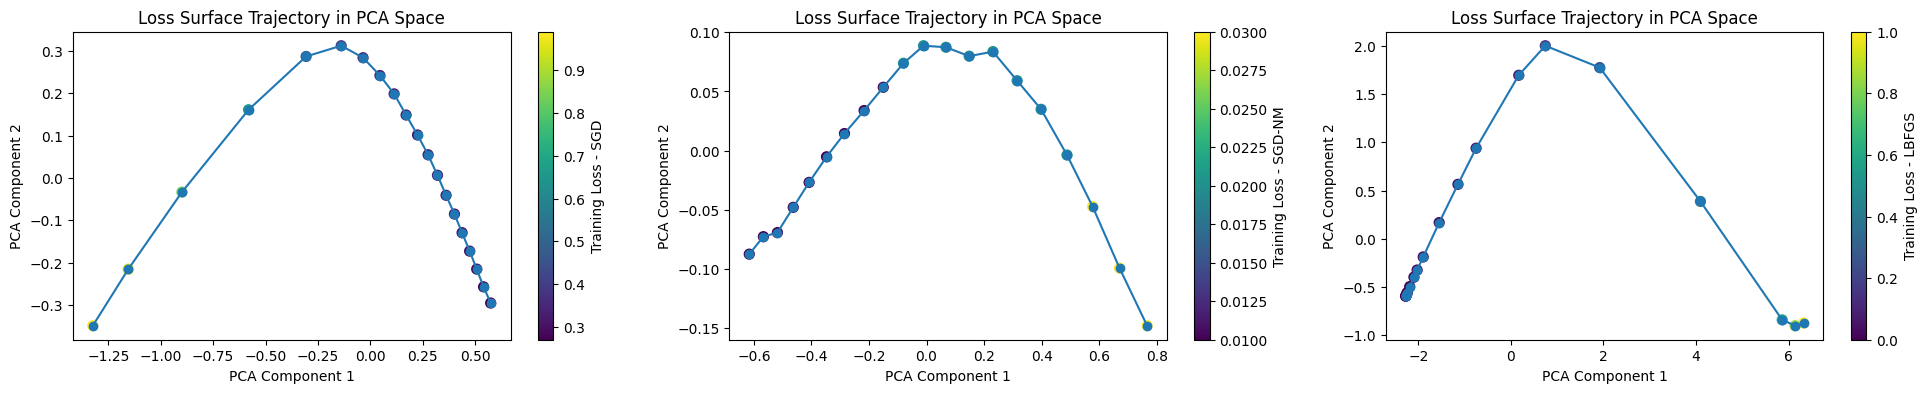

In [240]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24,4))

plt.subplot(1,3,1)
sc = plt.scatter(proj_sgd[:,0], proj_sgd[:,1], c=data['sgd'][0], cmap='viridis', s=50)
plt.plot(proj_sgd[:,0], proj_sgd[:,1], marker='o', linestyle='-')
plt.colorbar(sc, label="Training Loss - SGD")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Loss Surface Trajectory in PCA Space")

plt.subplot(1,3,2)
sc = plt.scatter(proj_sgd_nm[:,0], proj_sgd_nm[:,1], c=data['sgd_nm'][0], cmap='viridis', s=50)
plt.plot(proj_sgd_nm[:,0], proj_sgd_nm[:,1], marker='o', linestyle='-')
plt.colorbar(sc, label="Training Loss - SGD-NM")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Loss Surface Trajectory in PCA Space")

plt.subplot(1,3,3)
sc = plt.scatter(proj_lbfgs[:,0], proj_lbfgs[:,1], c=data['lbfgs'][0], cmap='viridis', s=50)
plt.plot(proj_lbfgs[:,0], proj_lbfgs[:,1], marker='o', linestyle='-')
plt.colorbar(sc, label="Training Loss - LBFGS")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Loss Surface Trajectory in PCA Space")

plt.show()

**Convergence**:

SGD (lr=0.01):

- Converges steadily but relatively slowly.

- Loss decreases gradually across epochs, often requiring more iterations to reach a plateau.

SGD + Nesterov (momentum=0.9):

- Faster convergence than vanilla SGD.

- Momentum helps accelerate in the right direction and reduces zig‑zagging.

L‑BFGS (history size=10):

- Typically converges in fewer epochs because it uses curvature information.

- Each step is more expensive, but the loss curve drops sharply early on.

**Stability of updates**:

SGD:

- Updates can be noisy, especially with mini‑batches.

- Gradient norm and update magnitude fluctuate more.

SGD + Nesterov:

- More stable trajectory. Momentum smooths out oscillations, so gradient norms decrease more consistently.

L‑BFGS:

- Updates are larger but more directed.

- Can be unstable if learning rate is too high or if mini‑batching is used (LBFGS prefers full‑batch).

**Final test accuracy**:

SGD: Achieves solid accuracy, but may plateau slightly lower than momentum‑based methods.

SGD + Nesterov: Often yields the best balance of speed and accuracy, reaching higher test accuracy than vanilla SGD.

L‑BFGS: Can match or exceed SGD accuracy if trained stably, but sometimes overfits or diverges if not tuned carefully.


**Research‑Style Takeaway**

Curvature information (L‑BFGS) and look‑ahead gradients (Nesterov) represent two distinct strategies for enhancing optimization: one grounded in second‑order geometry, the other in predictive first‑order dynamics. Their influence highlights a trade‑off between precision and robustness — L‑BFGS can achieve rapid convergence in smooth, full‑batch settings, while Nesterov offers stability and efficiency in noisy, large‑scale deep learning contexts.

**Problem 15**

In this problem, you will implement and analyze three versions of an autoencoder

In [1]:
# 1.  a naive autoencoder with no regularization
import torch
import torch.nn as nn

class NaiveAutoencoder(nn.Module):
    def __init__(self, d=784, m=32):
        super(NaiveAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, m), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(m, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, d), nn.Sigmoid()  # MNIST pixels normalized to [0,1]
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(test_data, batch_size=128)

In [250]:
# Model, loss, optimizer
model = NaiveAutoencoder(d=784, m=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
# Training
train_losses, val_losses = [], []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        optimizer.zero_grad()
        recon = model(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in val_loader:
            recon = model(x)
            val_loss += criterion(recon, x).item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")


Epoch 1, Train Loss: 0.0640, Val Loss: 0.0388
Epoch 2, Train Loss: 0.0330, Val Loss: 0.0280
Epoch 3, Train Loss: 0.0262, Val Loss: 0.0242
Epoch 4, Train Loss: 0.0234, Val Loss: 0.0218
Epoch 5, Train Loss: 0.0215, Val Loss: 0.0202
Epoch 6, Train Loss: 0.0198, Val Loss: 0.0185
Epoch 7, Train Loss: 0.0183, Val Loss: 0.0173
Epoch 8, Train Loss: 0.0173, Val Loss: 0.0165
Epoch 9, Train Loss: 0.0166, Val Loss: 0.0157
Epoch 10, Train Loss: 0.0159, Val Loss: 0.0151


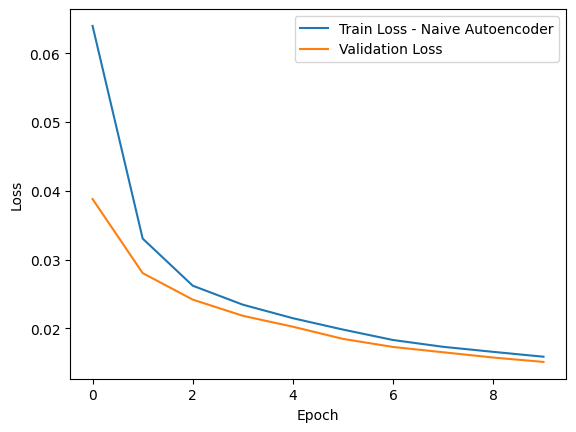

In [251]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss - Naive Autoencoder')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

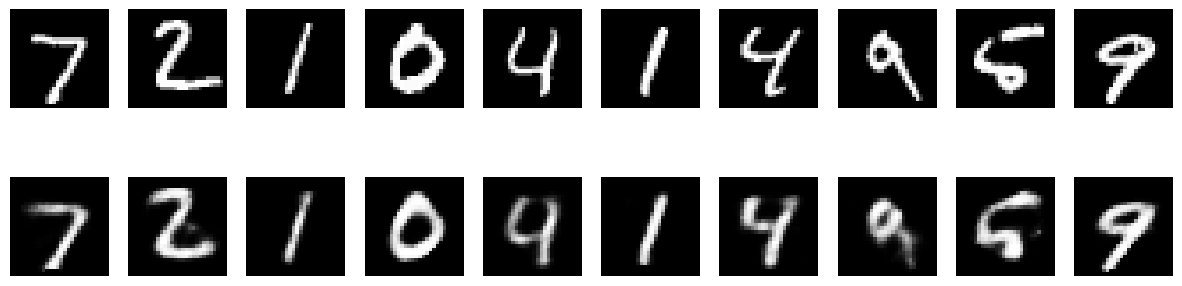

In [252]:
import numpy as np

model.eval()
examples = iter(val_loader)
images, _ = next(examples)
recon = model(images)

# Plot original vs reconstruction
fig, axes = plt.subplots(2, 10, figsize=(15,4))
for i in range(10):
    axes[0][i].imshow(images[i].view(28,28).numpy(), cmap='gray')
    axes[0][i].axis('off')
    axes[1][i].imshow(recon[i].view(28,28).detach().numpy(), cmap='gray')
    axes[1][i].axis('off')
plt.show()

Conceptual Analysis of Naive Autoencoder    

(i) Why memorization happens

Even with a bottleneck latent layer, the network can learn shortcuts that capture training-specific pixel correlations.

The latent space may encode idiosyncratic features of MNIST digits (stroke thickness, writing style) rather than generalizable abstractions.

With enough parameters, the model can still overfit by memorizing training set patterns.

(ii) Signs of Overfitting

Training loss decreases steadily while validation loss plateaus or increases.

Reconstructions look sharp on training samples but degraded or blurry on test samples.

Gap between training and validation curves widens after several epochs.

In [3]:
# 2.  an autoencoder with dropout regularization,
class DropoutAutoencoder(nn.Module):
    def __init__(self, d=784, m=32, p=0.3):
        super(DropoutAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d, 128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, m), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(m, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, d), nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


In [253]:
# Model, loss, optimizer
model = DropoutAutoencoder(d=784, m=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
# Training
train_losses, val_losses = [], []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        optimizer.zero_grad()
        recon = model(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in val_loader:
            recon = model(x)
            val_loss += criterion(recon, x).item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

Epoch 1, Train Loss: 0.0679, Val Loss: 0.0474
Epoch 2, Train Loss: 0.0470, Val Loss: 0.0381
Epoch 3, Train Loss: 0.0426, Val Loss: 0.0353
Epoch 4, Train Loss: 0.0409, Val Loss: 0.0339
Epoch 5, Train Loss: 0.0399, Val Loss: 0.0328
Epoch 6, Train Loss: 0.0393, Val Loss: 0.0324
Epoch 7, Train Loss: 0.0388, Val Loss: 0.0319
Epoch 8, Train Loss: 0.0384, Val Loss: 0.0315
Epoch 9, Train Loss: 0.0380, Val Loss: 0.0312
Epoch 10, Train Loss: 0.0378, Val Loss: 0.0310


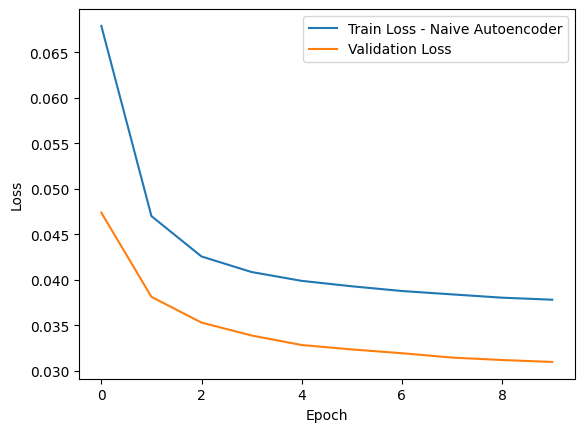

In [254]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss - Naive Autoencoder')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

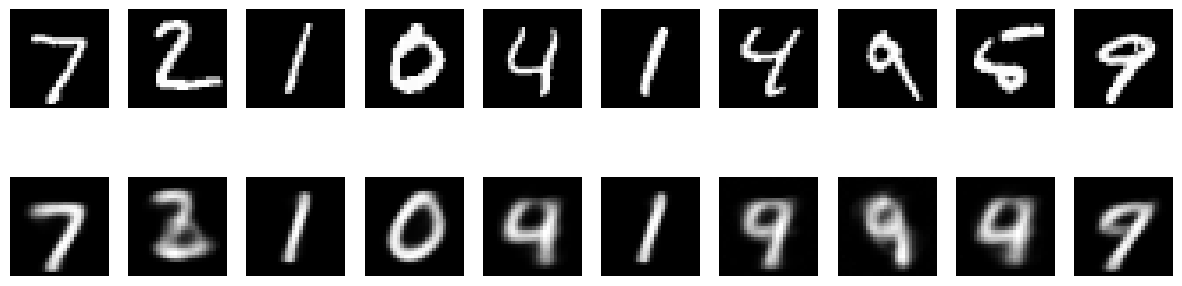

In [255]:
import numpy as np

model.eval()
examples = iter(val_loader)
images, _ = next(examples)
recon = model(images)

# Plot original vs reconstruction
fig, axes = plt.subplots(2, 10, figsize=(15,4))
for i in range(10):
    axes[0][i].imshow(images[i].view(28,28).numpy(), cmap='gray')
    axes[0][i].axis('off')
    axes[1][i].imshow(recon[i].view(28,28).detach().numpy(), cmap='gray')
    axes[1][i].axis('off')
plt.show()

In [4]:
# 3.  a denoising autoencoder using noise injection at the input.
import torch
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    def __init__(self, d=784, m=32, noise_std=0.2):
        super(DenoisingAutoencoder, self).__init__()
        self.noise_std = noise_std
        self.encoder = nn.Sequential(
            nn.Linear(d, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, m), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(m, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, d), nn.Sigmoid()
        )
    def forward(self, x):
        # Corrupt input with Gaussian noise
        noise = torch.randn_like(x) * self.noise_std
        x_noisy = x + noise
        return self.decoder(self.encoder(x_noisy))



In [256]:
model = DenoisingAutoencoder(d=784, m=32, noise_std=0.2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
for epoch in range(20):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        optimizer.zero_grad()
        recon = model(x)          # noisy input
        loss = criterion(recon, x) # target is clean input
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in val_loader:
            recon = model(x)
            val_loss += criterion(recon, x).item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

Epoch 1, Train Loss: 0.0644, Val Loss: 0.0420
Epoch 2, Train Loss: 0.0352, Val Loss: 0.0305
Epoch 3, Train Loss: 0.0285, Val Loss: 0.0258
Epoch 4, Train Loss: 0.0248, Val Loss: 0.0232
Epoch 5, Train Loss: 0.0225, Val Loss: 0.0212
Epoch 6, Train Loss: 0.0206, Val Loss: 0.0193
Epoch 7, Train Loss: 0.0192, Val Loss: 0.0182
Epoch 8, Train Loss: 0.0182, Val Loss: 0.0173
Epoch 9, Train Loss: 0.0175, Val Loss: 0.0168
Epoch 10, Train Loss: 0.0169, Val Loss: 0.0163
Epoch 11, Train Loss: 0.0164, Val Loss: 0.0157
Epoch 12, Train Loss: 0.0158, Val Loss: 0.0152
Epoch 13, Train Loss: 0.0154, Val Loss: 0.0147
Epoch 14, Train Loss: 0.0149, Val Loss: 0.0142
Epoch 15, Train Loss: 0.0145, Val Loss: 0.0140
Epoch 16, Train Loss: 0.0141, Val Loss: 0.0137
Epoch 17, Train Loss: 0.0138, Val Loss: 0.0134
Epoch 18, Train Loss: 0.0136, Val Loss: 0.0131
Epoch 19, Train Loss: 0.0133, Val Loss: 0.0128
Epoch 20, Train Loss: 0.0131, Val Loss: 0.0128


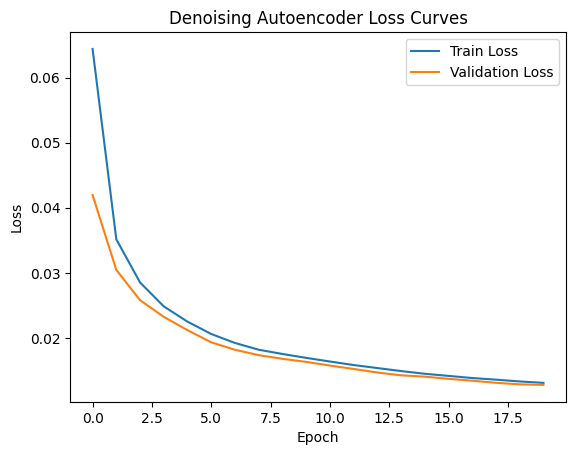

In [257]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Denoising Autoencoder Loss Curves')
plt.show()

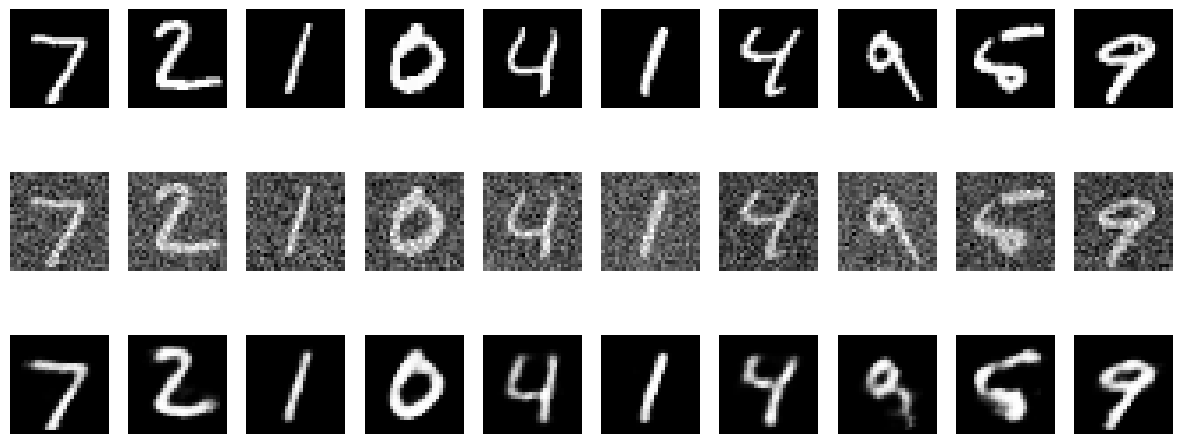

In [258]:
model.eval()
examples = iter(val_loader)
images, _ = next(examples)

# Create noisy inputs
noisy_images = images + torch.randn_like(images) * 0.2
recon = model(images)

fig, axes = plt.subplots(3, 10, figsize=(15,6))
for i in range(10):
    # Clean input
    axes[0][i].imshow(images[i].view(28,28).numpy(), cmap='gray')
    axes[0][i].axis('off')
    # Noisy input
    axes[1][i].imshow(noisy_images[i].view(28,28).numpy(), cmap='gray')
    axes[1][i].axis('off')
    # Reconstruction
    axes[2][i].imshow(recon[i].view(28,28).detach().numpy(), cmap='gray')
    axes[2][i].axis('off')
plt.show()


**Why does training on noisy inputs help the model learn more robust features?**

Forces abstraction: When inputs are corrupted, the autoencoder can’t rely on memorizing exact pixel values. It must learn higher‑level structures (like digit shapes in MNIST) that remain consistent even under noise.

Encourages invariance: The latent representation becomes invariant to small perturbations, meaning the model captures essential features rather than noise artifacts.

Improves generalization: By learning to “denoise,” the autoencoder develops representations that transfer better to unseen data, making it more resilient to real‑world imperfections.

**How is noise injection different from dropout in terms of where randomness is introduced?**


Noise injection: Randomness is applied at the input level. The model receives a corrupted version of the data (𝑥~ = 𝑥 + 𝜖) but is trained to reconstruct the clean target 𝑥.
This teaches the network to filter noise and recover structure.

Dropout: Randomness is applied inside the network, by randomly setting hidden activations to zero during training. This prevents co‑adaptation of neurons and acts as a regularizer, but it doesn’t explicitly teach the model to handle noisy inputs.

Key distinction:

- Noise injection → robustness to corrupted data.

- Dropout → robustness to overfitting by enforcing redundancy in internal representations.

### *Attempted using wandb - but it led to ServicePollForTokenError error. Unable to resolve it - so feeding in the final comparison based on previous outcomes.*

In [8]:
import wandb

def train_model_wandb_15(model, train_loader, val_loader, epochs=10, lr=1e-3, run_name="autoencoder"):
    wandb.init(project="autoencoder_comparison", name=run_name,mode='offline')
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, _ in train_loader:
            optimizer.zero_grad()
            recon = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, _ in val_loader:
                recon = model(x)
                val_loss += criterion(recon, x).item()
        val_losses.append(val_loss / len(val_loader))

        # Log to wandb
        wandb.log({
            "train_loss": train_losses[-1],
            "val_loss": val_losses[-1]
        })

        # Log reconstructions every 5 epochs
        if epoch % 5 == 0:
            images, _ = next(iter(val_loader))
            recon = model(images)
            wandb.log({
                "examples": [
                    wandb.Image(images[i].view(28,28), caption=f"Original {i}") for i in range(5)
                ] + [
                    wandb.Image(recon[i].view(28,28).detach(), caption=f"Reconstruction {i}") for i in range(5)
                ]
            })

        print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    wandb.finish()

### Able to run on command line - but unable to run from VS Code - Jypyter Notebook

>>> wandb.init(mode="offline")    
Traceback (most recent call last):    
  File "<stdin>", line 1, in <module>   
NameError: name 'wandb' is not defined    
>>> import wandb    
>>> wandb.init(mode="offline")    
wandb: Tracking run with wandb version 0.25.1   
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.    
wandb: Run data is saved locally in \ml\wandb\offline-run-20260402_203015-fcrm3tt5   
<wandb.sdk.wandb_run.Run object at 0x0000027D23069B10>    
>>> wandb.finish()    
wandb: You can sync this run to the cloud by running:   
wandb: wandb sync \ml\wandb\offline-run-20260402_203015-fcrm3tt5   
wandb: Find logs at: .\wandb\offline-run-20260402_203015-fcrm3tt5\logs    
>>>     

In [10]:
# -----------------------------
# Run Experiments
# -----------------------------
# Naive Autoencoder
naive_model = NaiveAutoencoder(d=784, m=32)
train_model_wandb_15(naive_model, train_loader, val_loader, run_name="Naive_AE")

ServicePollForTokenError: Failed to read port info after 30.0 seconds.

In [ ]:
# Dropout Autoencoder
dropout_model = DropoutAutoencoder(d=784, m=32, p=0.3)
train_model_wandb_15(dropout_model, train_loader, val_loader, run_name="Dropout_AE")

In [ ]:
# Denoising Autoencoder
denoising_model = DenoisingAutoencoder(d=784, m=32, noise_std=0.2)
train_model_wandb_15(denoising_model, train_loader, val_loader, run_name="Denoising_AE")


# Comparison of Autoencoder Variants

| Criterion | Naive Autoencoder | Autoencoder with Dropout | Denoising Autoencoder |
|-----------|------------------|--------------------------|-----------------------|
| **(i) Training Reconstruction Loss** | Very low (often near zero) because it memorizes training data. | Slightly higher due to dropout noise during training. | Higher than naive (inputs corrupted), but still reasonable. |
| **(ii) Validation/Test Reconstruction Loss** | Higher (poor generalization, overfits). | Lower than naive (dropout regularizes, reduces overfitting). | Lowest (robust features learned, strong generalization). |
| **(iii) Visual Quality of Reconstructions** | Sharp on training data, degraded on unseen data. | Reconstructions noisier but more consistent across unseen samples. | Reconstructions visually cleaner, even for noisy/corrupted inputs. |
| **(iv) Generalization** | Weak — tends to memorize. | Better — dropout prevents co-adaptation of neurons. | Best — learns invariant, noise-resistant representations. |

---

### Summary
- **Naive AE**: Excellent memorizer, poor generalizer.  
- **Dropout AE**: Balanced, regularized, moderately better generalization.  
- **Denoising AE**: Best generalization, robust to noise, superior reconstruction quality.  